In [1]:
import numpy as np

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import ResNet50

print("All libraries imported successfully!")

All libraries imported successfully!


Load CIFAR-10 Dataset


In [6]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training data:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing data:", x_test.shape)
print("Testing labels:", y_test.shape)

Training data: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing data: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [5]:
print(type(x_train))
print(type(y_train))
print(type(x_test))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


create the small dataset

In [7]:
num_train_per_class = 100
num_test_per_class = 20

train_indices = []
test_indices = []

for class_id in range(10):

    train_class_indices = np.where(
        y_train.flatten() == class_id
    )[0]

    test_class_indices = np.where(
        y_test.flatten() == class_id
    )[0]

    train_indices.extend(
        train_class_indices[:num_train_per_class]
    )

    test_indices.extend(
        test_class_indices[:num_test_per_class]
    )

x_train_small = x_train[train_indices]
y_train_small = y_train[train_indices]

x_test_small = x_test[test_indices]
y_test_small = y_test[test_indices]

print("Small training dataset:", x_train_small.shape)
print("Small testing dataset:", x_test_small.shape)

Small training dataset: (1000, 32, 32, 3)
Small testing dataset: (200, 32, 32, 3)


Define CIFAR-10 Class Names

In [8]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print("Number of classes:", len(class_names))

print("\nClasses:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Number of classes: 10

Classes:
0 : airplane
1 : automobile
2 : bird
3 : cat
4 : deer
5 : dog
6 : frog
7 : horse
8 : ship
9 : truck


Visualize Sample Images

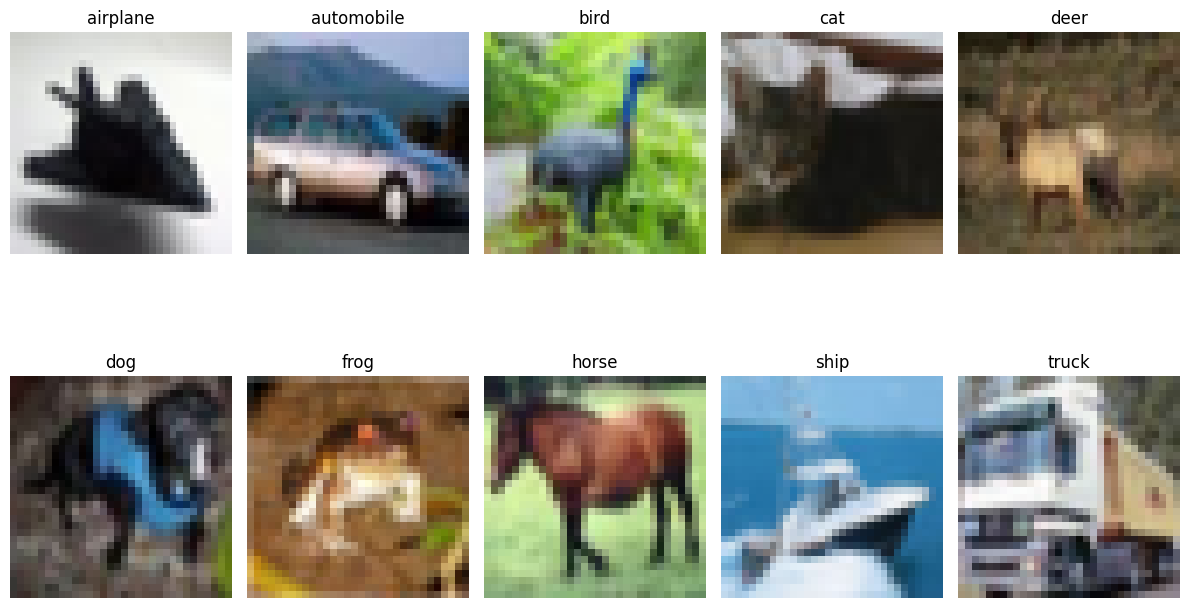

In [10]:
plt.figure(figsize=(12, 8))

for class_id in range(10):

    # Find the first image belonging to this class
    index = np.where(y_train_small == class_id)[0][0]

    plt.subplot(2, 5, class_id + 1)

    plt.imshow(x_train_small[index])

    plt.title(class_names[class_id])

    plt.axis("off")

plt.tight_layout()
plt.show()

Convert Labels into 1D

In [11]:
y_train_small = y_train_small.flatten()
y_test_small = y_test_small.flatten()

print("Training labels shape:", y_train_small.shape)
print("Testing labels shape:", y_test_small.shape)

Training labels shape: (1000,)
Testing labels shape: (200,)


Resize Images

In [12]:
IMG_SIZE = 96

x_train_resized = tf.image.resize(
    x_train_small,
    (IMG_SIZE, IMG_SIZE)
)

x_test_resized = tf.image.resize(
    x_test_small,
    (IMG_SIZE, IMG_SIZE)
)

print("Training images:", x_train_resized.shape)
print("Testing images:", x_test_resized.shape)

Training images: (1000, 96, 96, 3)
Testing images: (200, 96, 96, 3)


Create TensorFlow Dataset

In [13]:
BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices(
    (x_train_resized, y_train_small)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (x_test_resized, y_test_small)
)

train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE)

test_dataset = test_dataset.batch(BATCH_SIZE)

print("Training and testing datasets created successfully!")

Training and testing datasets created successfully!


Load Pre-trained VGG16

In [14]:
base_vgg16 = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

print("Pre-trained VGG16 loaded successfully!")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Pre-trained VGG16 loaded successfully!


Freeze VGG16 Layers

In [15]:
base_vgg16.trainable = False

print("VGG16 layers frozen.")

VGG16 layers frozen.


Create VGG16 Model

In [16]:
vgg16_model = Sequential([

    base_vgg16,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

vgg16_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Compile VGG16

In [17]:
vgg16_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("VGG16 compiled successfully!")

VGG16 compiled successfully!


Train VGG16

In [19]:
vgg16_history = vgg16_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=3
)

Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.4580 - loss: 1.5828 - val_accuracy: 0.4400 - val_loss: 1.7735
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 130s 4s/step - accuracy: 0.5430 - loss: 1.3687 - val_accuracy: 0.5350 - val_loss: 1.6530
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.5680 - loss: 1.2545 - val_accuracy: 0.5200 - val_loss: 1.6258


Evaluate VGG16

In [20]:
vgg16_loss, vgg16_accuracy = vgg16_model.evaluate(
    test_dataset
)

print("VGG16 Test Loss:", vgg16_loss)
print("VGG16 Test Accuracy:", vgg16_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.5200 - loss: 1.6258
VGG16 Test Loss: 1.6258211135864258
VGG16 Test Accuracy: 0.5199999809265137


Load Pre-trained ResNet50

In [21]:
base_resnet50 = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

print("Pre-trained ResNet50 loaded successfully!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Pre-trained ResNet50 loaded successfully!


Freeze ResNet50 Layers

In [22]:
base_resnet50.trainable = False

print("ResNet50 layers frozen.")

ResNet50 layers frozen.


Create ResNet50 Model

In [23]:
resnet50_model = Sequential([

    base_resnet50,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

resnet50_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Compile ResNet50

In [24]:
resnet50_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("ResNet50 compiled successfully!")

ResNet50 compiled successfully!


Train ResNet50

In [25]:
resnet50_history = resnet50_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=3
)

Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.2950 - loss: 2.3957 - val_accuracy: 0.5150 - val_loss: 1.4904
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.5650 - loss: 1.2915 - val_accuracy: 0.6000 - val_loss: 1.2557
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6590 - loss: 0.9749 - val_accuracy: 0.6200 - val_loss: 1.1809


Evaluate ResNet50

In [26]:
resnet50_loss, resnet50_accuracy = resnet50_model.evaluate(
    test_dataset
)

print("ResNet50 Test Loss:", resnet50_loss)
print("ResNet50 Test Accuracy:", resnet50_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6200 - loss: 1.1809
ResNet50 Test Loss: 1.1808505058288574
ResNet50 Test Accuracy: 0.6200000047683716


ResNet50 Accuracy Graph

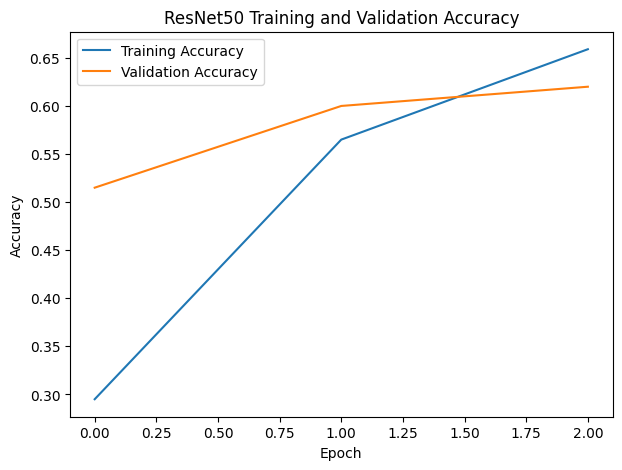

In [27]:
plt.figure(figsize=(7, 5))

plt.plot(
    resnet50_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    resnet50_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Training and Validation Accuracy")

plt.legend()
plt.show()